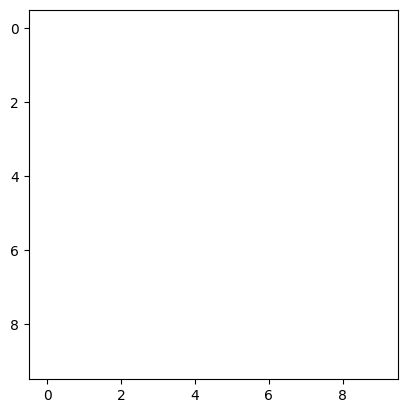

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


H = 10
W = 10
src = np.full((H,W,3), 255, dtype=np.uint8)
plt.imshow(src, cmap='gray')
plt.show()

Forward Projection: SRC -> DST

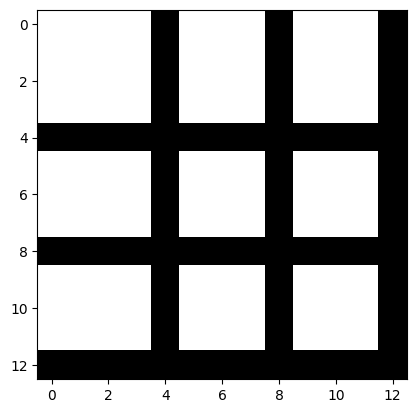

In [2]:
ratio = 1.3
dst = np.zeros((int(H * ratio), int(W * ratio), 3 ), dtype = np.uint8)

for h in range(H):
    for w in range(W):
        dst[int(h*ratio), int(w*ratio)] = src[h, w]

plt.imshow(dst)
plt.show()

Backward Projection: DST -> SRC

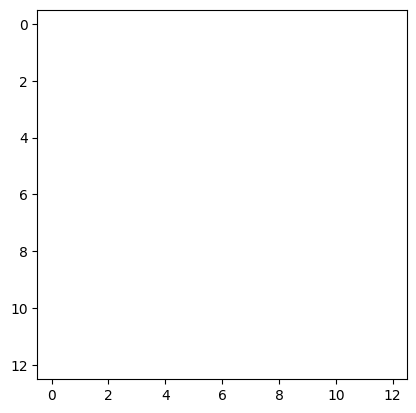

In [3]:
ratio = 1.3
dst = np.zeros((int(H * ratio), int(W * ratio), 3 ), dtype = np.uint8)

for h in range(dst.shape[0]):
    for w in range(dst.shape[1]):
        dst[h, w] = src[int(h/ratio), int(w/ratio)]

plt.imshow(dst)
plt.show()

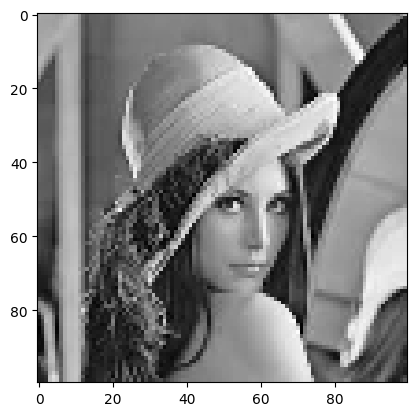

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

src= cv2.imread("images/lenna.jpeg", 0)

src = cv2.resize(src, (100,100))


plt.imshow(src, cmap='gray')
plt.show()


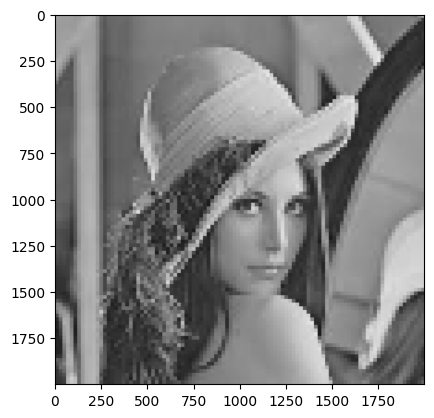

In [5]:
H, W = src.shape[:2]

ratio = 20
dst = np.zeros((int(H * ratio), int(W * ratio), 3 ), dtype = np.uint8)

for h in range(dst.shape[0]):
    for w in range(dst.shape[1]):
        dst[h, w] = src[int(h/ratio), int(w/ratio)]

plt.imshow(dst)
plt.show()

In [6]:
src = np.arange(1,10)
src = src.reshape(3,3)

print(src)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [7]:
scale = 3
H_src, W_src = src.shape[:2]

H_dst, W_dst = int(H_src * scale) , int(W_src * scale)

dst = np.zeros((H_dst, W_dst ), dtype= np.uint8)

h_dst = 2
w_dst = 4

scale = 3

h_src = int(h_dst / scale)
w_src = int(w_dst / scale)

up = h_src
left = w_src
down = min(up +1 , H_src - 1)
right = min(left + 1, W_src - 1)

print(up, left, down, right)


A = src[up, left]
B = src[up, right]
C = src[down, left]
D = src[down, right]

alpha = (w_dst / scale) - w_src
beta = (h_dst / scale) - h_src

print(alpha, beta)

E = A + alpha*(B - A)
F = C + alpha*(D - C)

X = E + beta * (F - E)

print(X)

0 1 1 2
0.33333333333333326 0.6666666666666666
4.333333333333333


In [ ]:

scale = 3
H_src, W_src = src.shape[:2]

H_dst, W_dst = int(H_src * scale) , int(W_src * scale)

dst = np.zeros((H_dst, W_dst ), dtype= np.uint8)

for h_dst in range(H_dst) :
    for w_dst in range(W_dst):

        h_src = int(h_dst / scale)
        w_src = int(w_dst / scale)
        
        up = h_src
        left = w_src
        down = min(up +1 , H_src - 1)
        right = min(left+1, W_src - 1)



        A = src[up, left].astype(float)
        B = src[up, right].astype(float)
        C = src[down, left].astype(float)
        D = src[down, right].astype(float)

        alpha = (w_dst / scale) - w_src
        beta = (h_dst / scale) - h_src

        E = A + alpha*(B - A)
        F = C + alpha*(D - C)

        X = E + beta * (F - E)

        dst[h_dst, w_dst] = np.clip(X, 0, 255)

print(dst)

[[1 1 1 2 2 2 3 3 3]
 [2 2 2 3 3 3 4 4 4]
 [3 3 3 4 4 4 5 5 5]
 [4 4 4 5 5 5 6 6 6]
 [5 5 5 6 6 6 7 7 7]
 [6 6 6 7 7 7 8 8 8]
 [7 7 7 8 8 8 9 9 9]
 [7 7 7 8 8 8 9 9 9]
 [7 7 7 8 8 8 9 9 9]]


CV2 쓸거면 cv2.resize 쓰면됨 cv2 메뉴얼 참고